In [7]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# define halo quants

# path to MDPL2 halos, galaxies, data
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 4 # grid size

with h5.File(halo_path, 'r') as hdf:
    hm_cut = hdf['mvir'][()] >= 1e13 # halo mass, h^-1 M_sun

    hpos = np.array([
        hdf['x'][()][hm_cut],
        hdf['y'][()][hm_cut], 
        hdf['z'][()][hm_cut],
    ], dtype=np.float64).T 

    hpos = np.mod(hpos, L_box)

    hvel = np.array([
        hdf['vx'][()][hm_cut],
        hdf['vy'][()][hm_cut], 
        hdf['vz'][()][hm_cut],
    ], dtype=np.float64).T 

In [ ]:
# load real space cf

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xihh.hdf5'

f = h5.File(save_path)

xi = f['xi'][()]

rbins = f['r_edges'][()]
rbins_c = f['r_cens'][()]


# load redshift space cf

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/s_mu_xi_hh.hdf5'

f = h5.File(save_path)

s_mu_xi = f['s_mu_xi'][()]

mu_bins = f['mu_edges'][()]
mu_bins_c = 0.5*(mu_bins[1:]+mu_bins[:-1])


<KeysViewHDF5 ['r_cens', 'r_edges', 'xi']>


In [4]:
# load
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'

mom_dict = {}
with h5.File(save_path+"halo_moments.h5", "r") as f:
    for key in f.keys():
        mom_dict[key] = f[key][:] # [:] loads the data into memory as a numpy array
        
    boxsize = f.attrs["boxsize"]
    rbins = f.attrs["rbins"]

In [19]:
# compact model
from scipy.interpolate import interp1d

def sigma_mod(x, sigma0, A_rho, sigma_rho):
    return np.sqrt(2 * sigma0**2 * (1 - A_rho * np.exp(-x / sigma_rho)))

def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)

class SkewTMeanInterpolator:
    """
    Pre-computes the relationship between (Delta_mean / sigma_v) and (omega, alpha)
    for a Skew-T distribution using the algebraic mean. 
    """
    def __init__(self, nu=6, alpha_bounds=(-15, 15), pts=1000):
        self.nu = nu
        
        # We can increase 'pts' since this is now an instantaneous vectorized calculation
        alphas = np.linspace(alpha_bounds[0], alpha_bounds[1], pts)
        
        # 1. Delta coefficient for Azzalini Skew-T
        delta = alphas / np.sqrt(1 + alphas**2)
        
        # 2. Exact Mean of standard Skew-T (xi=0, omega=1)
        # mu_z = delta * sqrt(nu / pi) * [Gamma((nu - 1) / 2) / Gamma(nu / 2)]
        gamma_factor = gamma((nu - 1) / 2) / gamma(nu / 2)
        mu_z = delta * np.sqrt(nu / np.pi) * gamma_factor
        
        # 3. Exact Standard Deviation of standard Skew-T
        var_z = (nu / (nu - 2)) - mu_z**2
        sig_z = np.sqrt(var_z)
        
        # 4. Ratio R = Delta_mean / sigma_v for standard distribution
        # Assuming Delta_mean = xi - mean = 0 - mu_z = -mu_z
        R_vals = -mu_z / sig_z
        
        # interp1d requires the x-array (R_vals) to be strictly monotonically increasing.
        # As alpha increases, R_vals strictly decreases, so we must reverse the arrays.
        if R_vals[-1] < R_vals[0]:
            valid_R = R_vals[::-1]
            valid_alphas = alphas[::-1]
        else:
            valid_R = R_vals
            valid_alphas = alphas
            
        # Interpolator 1: Ratio -> alpha (Upgraded to cubic for smooth analytical data)
        self.R_to_alpha = interp1d(valid_R, valid_alphas, kind='cubic', 
                                   bounds_error=False, 
                                   fill_value=(valid_alphas[0], valid_alphas[-1]))
        
        # Interpolator 2: alpha -> standard deviation
        self.alpha_to_sigZ = interp1d(alphas, sig_z, kind='cubic', 
                                      bounds_error=False, 
                                      fill_value=(sig_z[0], sig_z[-1]))

    def get_skew_params(self, delta_mean, sig_v):
        """Maps physical parameters (Delta_mean, sigma_v) to Skew-T parameters (omega, alpha)"""
        ratio = delta_mean / sig_v
        alpha = self.R_to_alpha(ratio)
        sig_z = self.alpha_to_sigZ(alpha)
        omega = sig_v / sig_z
        return omega, alpha
    
# Instantiate this globally so it isn't rebuilt on every function call
skew_interp = SkewTMeanInterpolator(nu=6)

sig_pars = np.array([0.20281935253098268, 27.382880273166126])
del_pars = np.array([47.766923483904314, 0.29581892896320244])

def Pv_compact(v, r_p, r_los, mean_vr, pars=[*sig_pars, *del_pars]):
    """
    Evaluates P(v | r_p, r_los, M) modeled as a Skew-T distribution using the compact model.
    """
    # 1. Coordinate transformations
    r = np.sqrt(r_p**2 + r_los**2)
    x = r - r_p
    
    # 2. Evaluate physical quantities via your models
    mu = mean_vr(r) * r_los/r  #vlos_mean_vec(r_p, r_los, M)
    sig_v = sigma_mod(x, 355, *pars[:2])
    
    # Enforce symmetry: Delta flips sign when rlos is negative
    sign_rlos = np.where(r_los != 0, np.sign(r_los), 1.0)
    delta_val = delta_mod(x, *pars[2:]) * sign_rlos
    
    # 3. Interpolate standard Skew-T parameters
    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    
    # 4. Location parameter is purely algebraic
    xi = mu + delta_val
    
    # 5. Evaluate Skew-T PDF
    nu = skew_interp.nu
    z = (v - xi) / omega
    
    # Azzalini's Skew-T formulation: 2 * t.pdf(z) * t.cdf(alpha * z * sqrt...)
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * t.pdf(z, nu) * t.cdf(arg, nu + 1)
    
    return pdf

def Pv_compact_direct(v, r_p, r_los, mean_vr, sig_v, delta):
    """
    Evaluates P(v | r_p, r_los, M) modeled as a Skew-T distribution using the compact model,
    with sig_v and delta passed in directly instead of via sigma_mod/delta_mod.
    """
    # 1. Coordinate transformations
    r = np.sqrt(r_p**2 + r_los**2)
    # 2. mu still evaluated via your model; sig_v and delta are supplied directly
    mu = mean_vr(r) * r_los/r  #vlos_mean_vec(r_p, r_los, M)
    # Enforce symmetry: Delta flips sign when rlos is negative
    sign_rlos = np.where(r_los != 0, np.sign(r_los), 1.0)
    delta_val = delta * sign_rlos
    # 3. Interpolate standard Skew-T parameters
    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    # 4. Location parameter is purely algebraic
    xi = mu + delta_val
    # 5. Evaluate Skew-T PDF
    nu = skew_interp.nu
    z = (v - xi) / omega
    # Azzalini's Skew-T formulation: 2 * t.pdf(z) * t.cdf(alpha * z * sqrt...)
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * t.pdf(z, nu) * t.cdf(arg, nu + 1)
    return pdf

mean_vr_interp = UnivariateSpline(rbins_c, mom_dict['m10'][()], s=0, k=5, ext=3)

In [8]:
gamma

<ufunc 'gamma'>

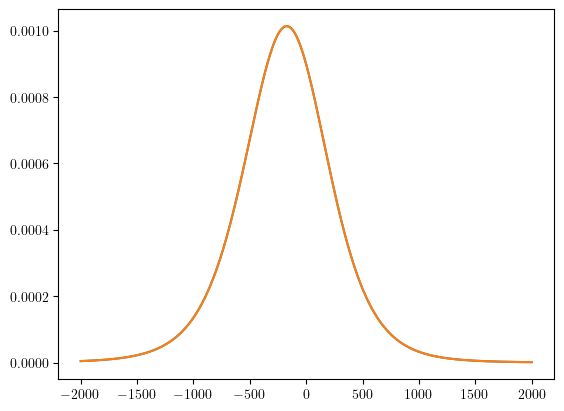

In [20]:
v = np.linspace(-2000, 2000, 1000)
r_p = 10
r_los = 15

x = np.sqrt(r_p**2 + r_los**2) - r_p

mean_vr_interp = UnivariateSpline(rbins_c, mom_dict['m10'][()], s=0, k=5, ext=3)

test_1 = Pv_compact(v, r_p, r_los, mean_vr_interp)

test_2 = Pv_compact_direct(v, r_p, r_los, mean_vr_interp, sigma_mod(x, 355, *sig_pars), delta_mod(x, *del_pars))

plt.plot(v, test_1)
plt.plot(v, test_2)

In [11]:
from halotools.mock_observables import tpcf_multipole

monopole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, 
    order=0
)
quadrupole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, 
    order=2
)
hexadecapole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, order=4)

In [12]:

uc = h/a/H # unit conversion

compact = lambda v, rp, rl: (1/uc)*Pv_compact(v/uc, rp, rl, mean_vr_interp)

compact_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xi,s=0),
    los_pdf_function=compact,
    limit=160, 
    epsilon=0.01,
    n=100,
)

compact_monopole = tpcf_multipole(
    compact_s_mu,
    mu_bins, 
    order=0
)
compact_quadrupole = tpcf_multipole(
    compact_s_mu, 
    mu_bins, 
    order=2
)
compact_hexadecapole = tpcf_multipole(
    compact_s_mu, 
    mu_bins, 
    order=4)

In [14]:
# load LPT preds

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/LPT/'


with h5.File(save_path+'lpt_2par_joint_fit.hdf5', 'r') as hdf:
    lpt_xi = hdf['xi_hh'][()]
    lpt_r = hdf['r_cens'][()]
    lpt_m10 = hdf['v12'][()]

In [15]:
# compute LPT multipoles

lpt_mean = UnivariateSpline(lpt_r, lpt_m10, s=0, k=5, ext=3)

lpt_compact = lambda v, rp, rl: (1/uc)*Pv_compact(v/uc, rp, rl, lpt_mean)

lpt_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=UnivariateSpline(lpt_r,
                                     lpt_xi, s=0),
    los_pdf_function=lpt_compact,
    limit=160, 
    epsilon=0.01,
    #n=300,
)

lpt_monopole = tpcf_multipole(
    lpt_s_mu,
    mu_bins, 
    order=0
)
lpt_quadrupole = tpcf_multipole(
    lpt_s_mu, 
    mu_bins, 
    order=2
)
lpt_hexadecapole = tpcf_multipole(
    lpt_s_mu, 
    mu_bins, 
    order=4)

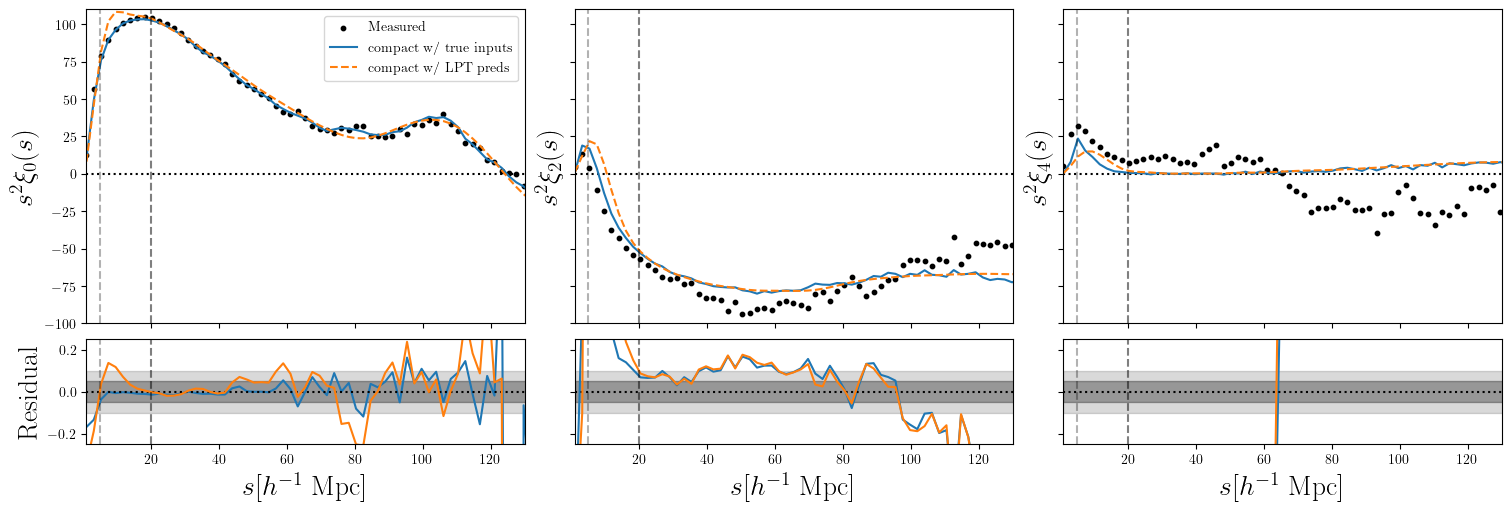

In [16]:
fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[compact_monopole, compact_quadrupole, compact_hexadecapole], label='compact w/ true inputs',)

lpt_multipoles = [lpt_monopole, lpt_quadrupole, lpt_hexadecapole]
multipoles = [monopole, quadrupole, hexadecapole]

for i, lm in enumerate(lpt_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*lm, label='compact w/ LPT preds', color='C1', ls='--')

    axes[1, i].plot(rbins_c, (lm-multipoles[i])/(np.abs(multipoles[i])+1e-8))

    axes[0, i].axvline(20, c='k', alpha=0.5, ls='--')
    axes[1, i].axvline(20, c='k', alpha=0.5, ls='--')

    axes[0, i].axvline(5, c='k', alpha=0.3, ls='--')
    axes[1, i].axvline(5, c='k', alpha=0.3, ls='--')

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 130))
axes[0, 1].set_xlim((1, 130))
axes[0, 2].set_xlim((1, 130))

axes[0, 0].legend()

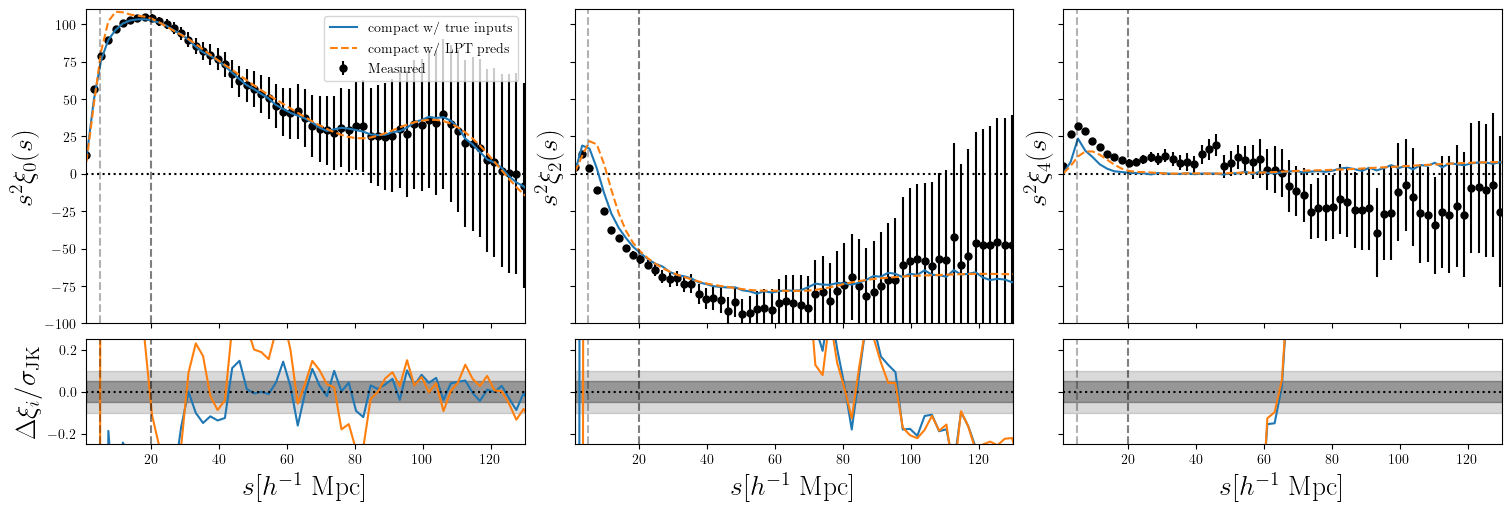

In [43]:
fig, axes = plot_multipoles_n_residuals(rbins_c, xi_ell, errs=xi_ell_std, preds=[compact_monopole, compact_quadrupole, compact_hexadecapole], label='compact w/ true inputs',)

lpt_multipoles = [lpt_monopole, lpt_quadrupole, lpt_hexadecapole]
multipoles = xi_ell #[monopole, quadrupole, hexadecapole]

for i, lm in enumerate(lpt_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*lm, label='compact w/ LPT preds', color='C1', ls='--')

    axes[1, i].plot(rbins_c, (lm-multipoles[i])/xi_ell_std[i])

    axes[0, i].axvline(20, c='k', alpha=0.5, ls='--')
    axes[1, i].axvline(20, c='k', alpha=0.5, ls='--')

    axes[0, i].axvline(5, c='k', alpha=0.3, ls='--')
    axes[1, i].axvline(5, c='k', alpha=0.3, ls='--')

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 130))
axes[0, 1].set_xlim((1, 130))
axes[0, 2].set_xlim((1, 130))

axes[0, 0].legend()

In [ ]:
# re-fit compact model to multipoles

import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.optimize import least_squares

p0 = np.concatenate([sig_pars, 
                     del_pars,
                    ])

Bounds = np.array([(np.min((0, np.sign(par)*np.inf)), np.max((0, np.sign(par)*np.inf))) for par in p0]).T

xi_spline = UnivariateSpline(rbins_c, xi, s=0)  # fixed across the fit -- build once

def residuals(params, mono_sim, quad_sim, hexa_sim, w_mono, w_quad, w_hexa, mask):
    sigv_pars = params[:2]
    delta_pars = params[2:]

    def compact(v, rp, rl):
        r = np.sqrt(rp**2 + rl**2)
        x = r - rp
        sig_v = sigma_mod(x, 355, *sigv_pars)
        delta = delta_mod(x, *delta_pars)
        return (1/uc) * Pv_compact_direct(v/uc, rp, rl, mean_vr_interp, sig_v, delta)

    s_mu = simps_integrate(
        s_c=rbins_c, mu_c=mu_bins_c,
        twopcf_function=xi_spline,
        los_pdf_function=compact,
        limit=160,
        epsilon=0.01,
        n=100,
    )
    mono = tpcf_multipole(s_mu, mu_bins, order=0)
    quad = tpcf_multipole(s_mu, mu_bins, order=2)
    hexa = tpcf_multipole(s_mu, mu_bins, order=4)

    return np.concatenate([
        ((mono - mono_sim) / w_mono)[mask],
        ((quad - quad_sim) / w_quad)[mask],
        ((hexa - hexa_sim) / w_hexa)[mask],
    ])

In [11]:
# load JK estimates from pycorr

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/xi_smu_hh_pycorr.hdf5'


with h5.File(save_path, 'r') as f:
    xi_ell = f['xi_ell'][()]
    xi_ell_cov = f['xi_ell_cov'][()]

nells = 3
xi_ell_std = np.array(np.array_split(np.diag(xi_ell_cov)**0.5, nells))

In [52]:
Bounds.shape

(4, 2)

In [62]:
monopole, quadrupole, hexadecapole = xi_ell
w_mono, w_quad, w_hexa = xi_ell_std

result = least_squares(
    residuals, p0, bounds=Bounds,
    args=(monopole, quadrupole, hexadecapole, w_mono, w_quad, w_hexa, (rbins_c>20)),
    verbose=2,
    max_nfev=300,
)

bf_pars = result.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.0313e+01                                    2.08e+02    
       1              2         4.7462e+01      2.29e+01       6.30e+00       1.02e+02    
       2              3         4.0101e+01      7.36e+00       1.04e+01       2.83e+01    
       3              4         3.9544e+01      5.57e-01       2.19e+01       1.17e+01    
       4              6         3.8450e+01      1.09e+00       6.50e+00       7.25e+00    
       5              7         3.8359e+01      9.17e-02       4.85e+00       1.64e+00    
       6              9         3.8348e+01      1.11e-02       3.56e+00       8.86e-01    
       7             10         3.8340e+01      7.66e-03       2.79e-01       6.01e-02    
       8             11         3.8330e+01      1.04e-02       5.42e-01       1.97e-02    
       9             12         3.8316e+01      1.36e-02       1.08e+00       2.78e-02    

In [15]:
sig_v_best = np.array([369.9756603,  357.31312659, 377.53537648, 387.02987947, 308.30116379, 235.50382169, 165.73218795, 776.42329891])

delta_best = np.array([-123.75340039,  334.41540565,   407.30998528,   373.14147083, -63.54389664,   -39.7970635,  -53.08432675, -1322.16125687])


sig_v_interp = UnivariateSpline(x_knots, sig_v_best, s=0, k=3, ext=3)
del_interp = UnivariateSpline(x_knots, delta_best, s=0, k=3, ext=3)

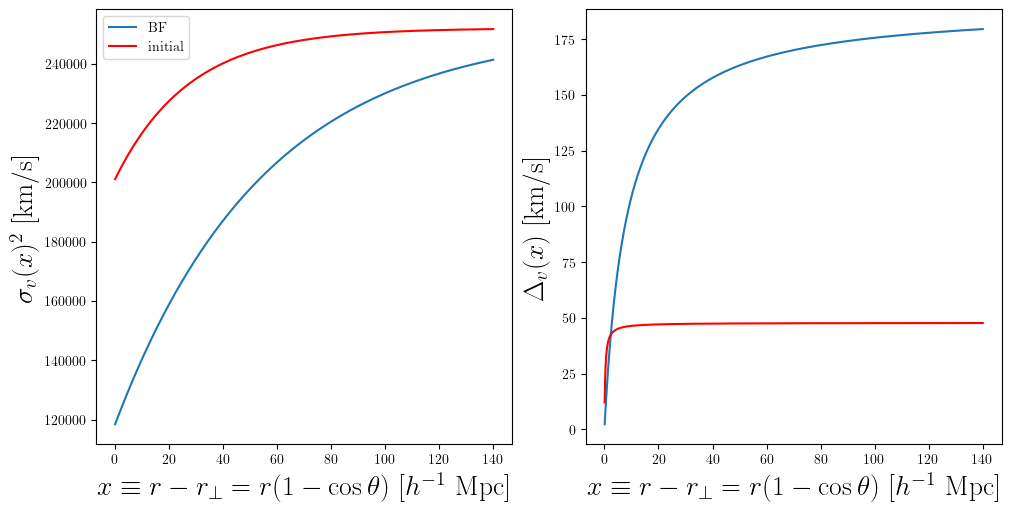

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

xs = np.linspace(0.1, 140, 1000)

ax[0].plot(xs, sigma_mod(xs, 355, *bf_pars[:2])**2, label='BF')
ax[0].plot(xs, sigma_mod(xs, 355, *sig_pars)**2, c='r', label='initial')
ax[0].set_ylabel(r'$\sigma_v(x)^2$ [km/s]')
ax[0].set_xlabel(r'$x\equiv r-r_\perp = r(1-\cos\theta)$ [$h^{-1}$ Mpc]')

ax[1].plot(xs, delta_mod(xs, *bf_pars[2:]))
ax[1].plot(xs, delta_mod(xs, *del_pars), c='r')
ax[1].set_ylabel(r'$\Delta_v(x)$ [km/s]')
ax[1].set_xlabel(r'$x\equiv r-r_\perp = r(1-\cos\theta)$ [$h^{-1}$ Mpc]')

ax[0].legend()

In [64]:

uc = h/a/H # unit conversion

compact_BF = lambda v, rp, rl: (1/uc)*Pv_compact(v/uc, rp, rl, mean_vr_interp, bf_pars)

compact_BF_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xi,s=0),
    los_pdf_function=compact_BF,
    limit=160, 
    epsilon=0.01,
    n=100,
)

compact_BF_monopole = tpcf_multipole(
    compact_BF_s_mu,
    mu_bins, 
    order=0
)
compact_BF_quadrupole = tpcf_multipole(
    compact_BF_s_mu, 
    mu_bins, 
    order=2
)
compact_BF_hexadecapole = tpcf_multipole(
    compact_BF_s_mu, 
    mu_bins, 
    order=4)

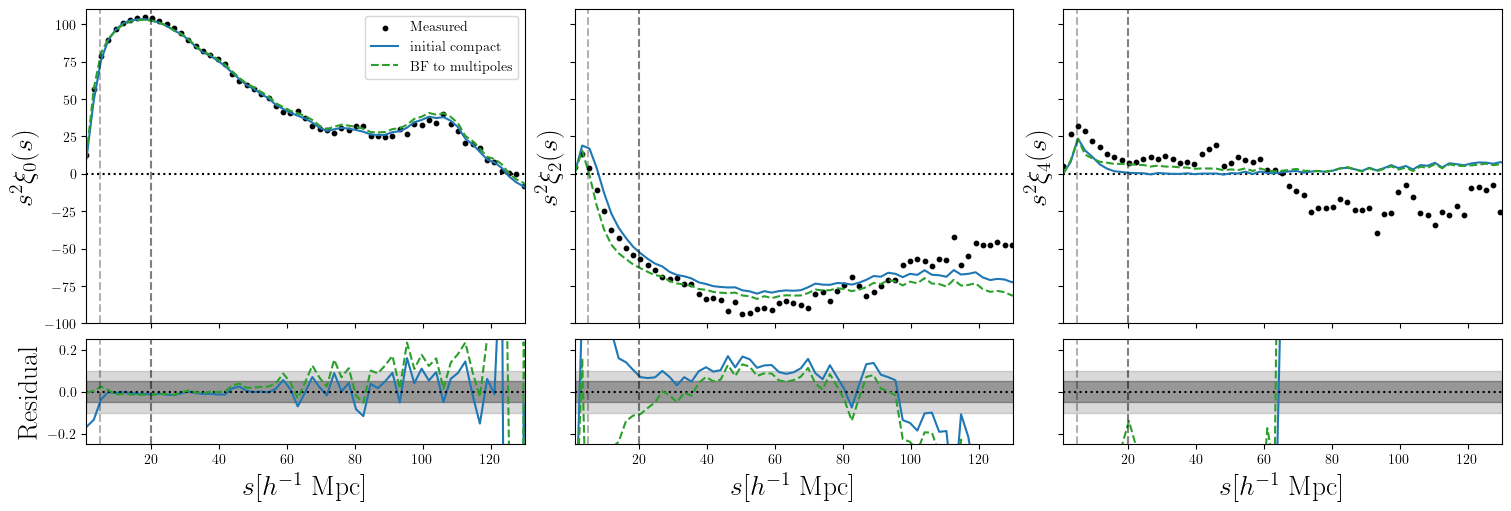

In [65]:
fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[compact_monopole, compact_quadrupole, compact_hexadecapole], label='initial compact',)

compact_BF_multipoles = [compact_BF_monopole, compact_BF_quadrupole, compact_BF_hexadecapole]
multipoles = [monopole, quadrupole, hexadecapole]

for i, lm in enumerate(compact_BF_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*lm, label=r'BF to multipoles', color='C2', ls='--')

    axes[1, i].plot(rbins_c, (lm-multipoles[i])/(np.abs(multipoles[i])+1e-8), c='C2', ls='--')

    axes[0, i].axvline(20, c='k', alpha=0.5, ls='--')
    axes[1, i].axvline(20, c='k', alpha=0.5, ls='--')

    axes[0, i].axvline(5, c='k', alpha=0.3, ls='--')
    axes[1, i].axvline(5, c='k', alpha=0.3, ls='--')

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 130))
axes[0, 1].set_xlim((1, 130))
axes[0, 2].set_xlim((1, 130))

axes[0, 0].legend()